# 2HW. Классификация цифр SVHN

## 1. Данные

Цветные изображения цифр из номеров домов. В `.mat` файлах: изображения — `(32, 32, 3, N)`, метки — `(N, 1)`.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.io import loadmat
from sklearn.model_selection import train_test_split

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

HW_DIR = Path("2HW")
if not HW_DIR.exists():
    HW_DIR = Path(".")

TRAIN_PATH = HW_DIR / "train_32x32.mat"
TEST_PATH = HW_DIR / "test_32x32.mat"

if str(HW_DIR) not in sys.path:
    sys.path.append(str(HW_DIR))

from simple_nn import (  # noqa: E402
    Adam,
    BatchNormLayer,
    CrossEntropyLoss,
    FullyConnectedLayer,
    Momentum,
    ReluLayer,
    SGD,
    Sequential,
    evaluate,
    gradient_check_layer,
    gradient_check_model,
    fit,
)

RANDOM_STATE = 122
rng = np.random.default_rng(RANDOM_STATE)

In [2]:
def load_svhn_mat(path):
    raw = loadmat(path)
    X = raw["X"].transpose(3, 0, 1, 2)
    y = raw["y"].reshape(-1).astype(int)
    y[y == 10] = 0
    return X, y


X_train_images, y_train_all = load_svhn_mat(TRAIN_PATH)
X_test_images, y_test = load_svhn_mat(TEST_PATH)

print("Train images:", X_train_images.shape, X_train_images.dtype)
print("Train labels:", y_train_all.shape, y_train_all.min(), y_train_all.max())
print("Test images:", X_test_images.shape, X_test_images.dtype)
print("Test labels:", y_test.shape, y_test.min(), y_test.max())

Train images: (73257, 32, 32, 3) uint8
Train labels: (73257,) 0 9
Test images: (26032, 32, 32, 3) uint8
Test labels: (26032,) 0 9


### 1.1. Баланс классов

In [3]:
def label_counts(y, split):
    counts = pd.Series(y, name="digit").value_counts().sort_index()
    return pd.DataFrame({"digit": counts.index, "count": counts.values, "split": split})


class_balance = pd.concat(
    [label_counts(y_train_all, "train"), label_counts(y_test, "test")],
    ignore_index=True,
)
class_balance

,digit,count,split
0,0,4948,train
1,1,13861,train
2,2,10585,train
3,3,8497,train
4,4,7458,train
5,5,6882,train
6,6,5727,train
7,7,5595,train
8,8,5045,train
9,9,4659,train


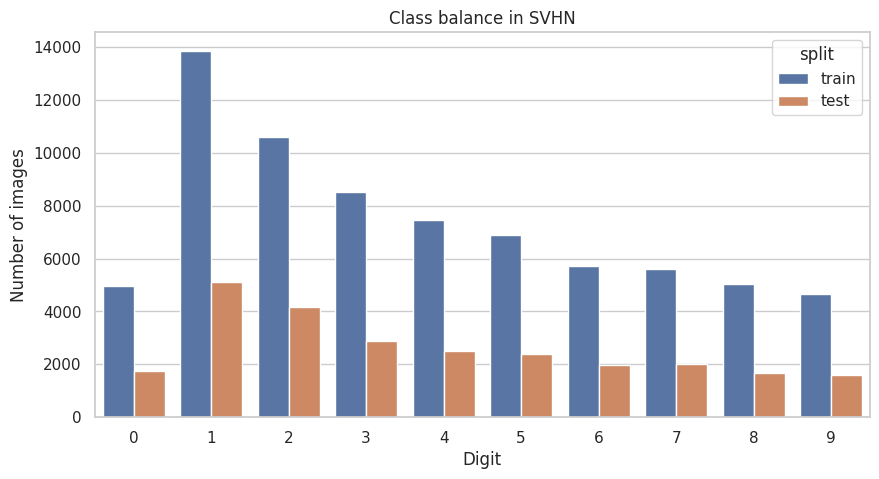

In [4]:
sns.barplot(data=class_balance, x="digit", y="count", hue="split")
plt.title("Class balance in SVHN")
plt.xlabel("Digit")
plt.ylabel("Number of images")
plt.show()

### 1.2. Примеры изображений

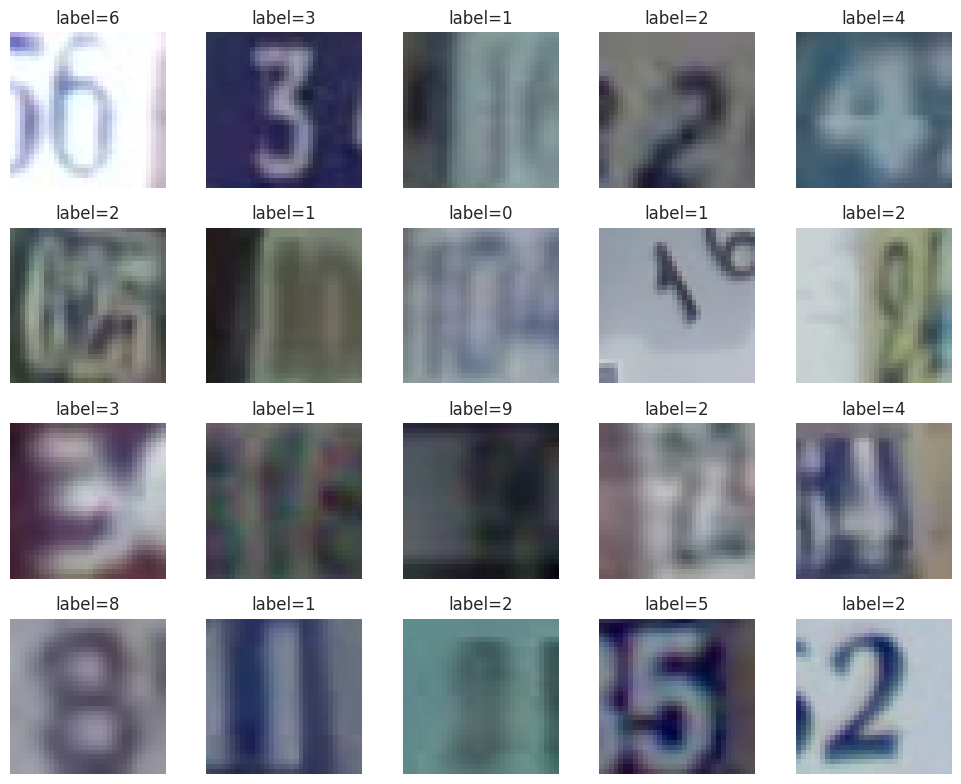

In [5]:
sample_ids = rng.choice(len(X_train_images), size=20, replace=False)
fig, axes = plt.subplots(4, 5, figsize=(10, 8))
for ax, image_id in zip(axes.ravel(), sample_ids):
    ax.imshow(X_train_images[image_id])
    ax.set_title(f"label={y_train_all[image_id]}")
    ax.axis("off")
plt.tight_layout()
plt.show()

## 2. Подготовка данных

Усредняем RGB-каналы, делим на 255 и разворачиваем изображение в 1024 признака. Из train выделяем 10 000 примеров для validation. Среднее и стандартное отклонение считаем только по оставшемуся train.

In [6]:
def images_to_features(images):
    grayscale = images.astype(np.float32).mean(axis=3) / 255.0
    return grayscale.reshape(len(images), -1)


X_train_features_all = images_to_features(X_train_images)
X_test_features = images_to_features(X_test_images)

X_train_raw, X_val_raw, y_train, y_val = train_test_split(
    X_train_features_all,
    y_train_all,
    test_size=10_000,
    random_state=RANDOM_STATE,
    stratify=y_train_all,
)

feature_mean = X_train_raw.mean(axis=0, keepdims=True)
feature_std = X_train_raw.std(axis=0, keepdims=True) + 1e-6

X_train = (X_train_raw - feature_mean) / feature_std
X_val = (X_val_raw - feature_mean) / feature_std
X_test = (X_test_features - feature_mean) / feature_std

print("Train:", X_train.shape, y_train.shape)
print("Validation:", X_val.shape, y_val.shape)
print("Test:", X_test.shape, y_test.shape)

Train: (63257, 1024) (63257,)
Validation: (10000, 1024) (10000,)
Test: (26032, 1024) (26032,)


In [7]:
pixel_summary = pd.DataFrame(
    {
        "split": ["train", "validation", "test"],
        "mean": [X_train.mean(), X_val.mean(), X_test.mean()],
        "std": [X_train.std(), X_val.std(), X_test.std()],
        "min": [X_train.min(), X_val.min(), X_test.min()],
        "max": [X_train.max(), X_val.max(), X_test.max()],
    }
)
pixel_summary

,split,mean,std,min,max
0,train,-0.000003,0.999998,-2.461806,3.136271
1,validation,-0.010305,0.996342,-2.396762,3.136271
2,test,0.032335,1.134294,-2.463274,3.136271


## 3. Проверка градиентов

До обучения проверяем сеть и отдельные слои. Перед каждым обновлением весов — по две координаты каждого тензора параметров на восьми примерах текущего батча, включая L2.

In [8]:
small_rng = np.random.default_rng(RANDOM_STATE)
X_small = small_rng.normal(size=(6, 4))
y_small = np.array([0, 1, 2, 1, 0, 2])

small_model = Sequential(
    [
        FullyConnectedLayer(4, 5, rng=small_rng),
        ReluLayer(),
        FullyConnectedLayer(5, 3, rng=small_rng),
    ]
)
model_check = pd.DataFrame(
    gradient_check_model(
        small_model,
        CrossEntropyLoss(),
        X_small,
        y_small,
        l2=1e-3,
        num_checks=5,
    )
)
model_check.groupby("parameter")["relative_error"].max().reset_index()

,parameter,relative_error
0,layer0.W,2.122937e-09
1,layer0.b,4.019072e-10
2,layer2.W,1.193071e-09
3,layer2.b,2.498591e-09


In [9]:
layer_rng = np.random.default_rng(RANDOM_STATE)
layer_checks = []

fc_layer = FullyConnectedLayer(4, 3, rng=layer_rng)
layer_checks.extend(
    gradient_check_layer(fc_layer, layer_rng.normal(size=(5, 4)), layer_rng.normal(size=(5, 3)))
)

relu_layer = ReluLayer()
layer_checks.extend(
    gradient_check_layer(relu_layer, layer_rng.normal(size=(5, 4)), layer_rng.normal(size=(5, 4)))
)

bn_layer = BatchNormLayer(4)
layer_checks.extend(
    gradient_check_layer(bn_layer, layer_rng.normal(size=(6, 4)), layer_rng.normal(size=(6, 4)))
)

layer_check_df = pd.DataFrame(layer_checks)
layer_check_df.groupby("parameter")["relative_error"].max().reset_index()

,parameter,relative_error
0,W,5.130746e-10
1,b,2.256341e-11
2,beta,8.709310e-12
3,gamma,1.383487e-11
4,input,5.961493e-10


В проверках слоёв ориентир — относительная ошибка менее `1e-5`. Во время обучения: `|аналитический − численный| ≤ 1e-5 + 1e-3 × max(|аналитический|, |численный|)`. Проверки не меняют веса и статистики BatchNorm.

## 4. Обучение

Архитектура: `FC → ReLU → FC`. В варианте с BatchNorm нормализация стоит перед ReLU.

In [10]:
INPUT_DIM = X_train.shape[1]
NUM_CLASSES = 10
HIDDEN_DIM = 32
BATCH_SIZE = 1024
L2 = 1e-4


def make_model(hidden_dim=HIDDEN_DIM, use_batchnorm=False, random_state=RANDOM_STATE):
    model_rng = np.random.default_rng(random_state)
    layers = [FullyConnectedLayer(INPUT_DIM, hidden_dim, rng=model_rng)]
    if use_batchnorm:
        layers.append(BatchNormLayer(hidden_dim))
    layers.extend(
        [
            ReluLayer(),
            FullyConnectedLayer(hidden_dim, NUM_CLASSES, rng=model_rng),
        ]
    )
    return Sequential(layers)


def make_optimizer(name, learning_rate):
    if name == "SGD":
        return SGD(learning_rate=learning_rate)
    if name == "Momentum":
        return Momentum(learning_rate=learning_rate, momentum=0.9)
    if name == "Adam":
        return Adam(learning_rate=learning_rate)
    raise ValueError(f"Unknown optimizer: {name}")


def train_model(model, optimizer, epochs, batch_size=BATCH_SIZE, l2=L2, random_state=RANDOM_STATE):
    return pd.DataFrame(
        fit(
            model,
            optimizer,
            X_train,
            y_train,
            X_val,
            y_val,
            epochs=epochs,
            batch_size=batch_size,
            l2=l2,
            random_state=random_state,
            gradient_checks=2,
        )
    )

### 4.1. Подбор learning rate

Для каждой пары «оптимизатор / BatchNorm» проверяем три LR по 20 эпох. Выбираем максимум validation accuracy; при равенстве — меньший loss. Сохраняем веса и статистики BatchNorm выбранной эпохи.

In [11]:
TUNING_EPOCHS = 20
model_configs = [
    {
        "model_name": "SGD",
        "optimizer": "SGD",
        "batchnorm": False,
        "learning_rates": [0.01, 0.03, 0.1],
    },
    {
        "model_name": "Momentum",
        "optimizer": "Momentum",
        "batchnorm": False,
        "learning_rates": [0.001, 0.003, 0.01],
    },
    {
        "model_name": "Adam",
        "optimizer": "Adam",
        "batchnorm": False,
        "learning_rates": [0.0003, 0.001, 0.003],
    },
    {
        "model_name": "Momentum + BatchNorm",
        "optimizer": "Momentum",
        "batchnorm": True,
        "learning_rates": [0.01, 0.03, 0.1],
    },
    {
        "model_name": "Adam + BatchNorm",
        "optimizer": "Adam",
        "batchnorm": True,
        "learning_rates": [0.0003, 0.001, 0.003],
    },
]

tuning_histories = []
tuning_rows = []
candidate_models = {}

for config in model_configs:
    for learning_rate in config["learning_rates"]:
        model = make_model(use_batchnorm=config["batchnorm"])
        history = train_model(
            model, make_optimizer(config["optimizer"], learning_rate), TUNING_EPOCHS
        )
        history = history.assign(
            model_name=config["model_name"],
            optimizer=config["optimizer"],
            batchnorm=config["batchnorm"],
            learning_rate=learning_rate,
        )
        tuning_histories.append(history)
        best_row = (
            history.sort_values(
                ["val_accuracy", "val_loss", "epoch"], ascending=[False, True, True]
            )
            .iloc[0]
            .to_dict()
        )
        restored = evaluate(model, CrossEntropyLoss(), X_val, y_val, batch_size=BATCH_SIZE, l2=L2)
        np.testing.assert_allclose(
            restored["accuracy"], best_row["val_accuracy"], rtol=0, atol=1e-12
        )
        np.testing.assert_allclose(restored["loss"], best_row["val_loss"], rtol=0, atol=1e-12)
        best_row["elapsed_sec"] = history["elapsed_sec"].iloc[-1]
        tuning_rows.append(best_row)
        candidate_models[(config["model_name"], learning_rate)] = model
        print(f"{config['model_name']}, lr={learning_rate}: val={best_row['val_accuracy']:.4f}")

tuning_history = pd.concat(tuning_histories, ignore_index=True)
tuning_summary = pd.DataFrame(tuning_rows).sort_values(
    ["val_accuracy", "val_loss", "epoch"], ascending=[False, True, True]
)
tuning_summary[["model_name", "learning_rate", "epoch", "val_loss", "val_accuracy"]]

SGD, lr=0.01: val=0.6386


SGD, lr=0.03: val=0.7156


SGD, lr=0.1: val=0.7475


Momentum, lr=0.001: val=0.6356


Momentum, lr=0.003: val=0.7183


...

Momentum + BatchNorm, lr=0.1: val=0.7778


Adam + BatchNorm, lr=0.0003: val=0.7148


Adam + BatchNorm, lr=0.001: val=0.7679


Adam + BatchNorm, lr=0.003: val=0.7835


,model_name,learning_rate,epoch,val_loss,val_accuracy
14,Adam + BatchNorm,0.0030,20,0.755621,0.7835
8,Adam,0.0030,20,0.763253,0.7807
10,Momentum + BatchNorm,0.0300,20,0.788680,0.7784
11,Momentum + BatchNorm,0.1000,20,0.797187,0.7778
7,Adam,0.0010,19,0.807405,0.7699
13,Adam + BatchNorm,0.0010,20,0.814302,0.7679
5,Momentum,0.0100,20,0.830089,0.7637
9,Momentum + BatchNorm,0.0100,20,0.862154,0.7527
2,SGD,0.1000,20,0.883689,0.7475
6,Adam,0.0003,20,0.941306,0.7328


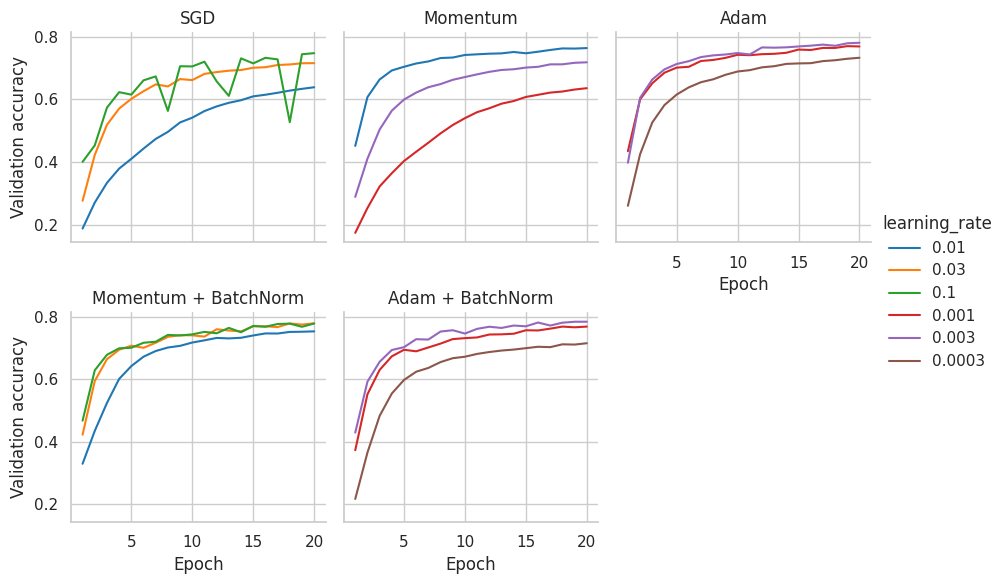

Checked training steps: 18600
Checked gradients: 178560
Max error / tolerance: 7e-05


In [12]:
grid = sns.relplot(
    data=tuning_history.assign(learning_rate=tuning_history["learning_rate"].map("{:g}".format)),
    x="epoch",
    y="val_accuracy",
    hue="learning_rate",
    col="model_name",
    col_wrap=3,
    kind="line",
    palette="tab10",
    facet_kws={"sharey": True},
    height=3,
)
grid.set_titles("{col_name}")
grid.set_axis_labels("Epoch", "Validation accuracy")
plt.show()

steps_per_epoch = (len(X_train) + BATCH_SIZE - 1) // BATCH_SIZE
assert (tuning_history["gradient_steps"] == steps_per_epoch).all()
assert (tuning_history["gradient_max_error"] <= 1).all()
print("Checked training steps:", int(tuning_history["gradient_steps"].sum()))
print("Checked gradients:", int(tuning_history["gradient_checks"].sum()))
print("Max error / tolerance:", round(tuning_history["gradient_max_error"].max(), 6))

### 4.2. Оптимизаторы и BatchNorm

Сравниваем лучший LR каждой конфигурации. Train и validation оцениваются после эпохи в режиме inference, с одинаковой L2.

In [13]:
comparison_summary = tuning_summary.groupby("model_name", sort=False).head(1).copy()
comparison_history = tuning_history.merge(
    comparison_summary[["model_name", "learning_rate"]],
    on=["model_name", "learning_rate"],
    how="inner",
    validate="many_to_one",
)
trained_models = {
    row.model_name: candidate_models[(row.model_name, row.learning_rate)]
    for row in comparison_summary.itertuples()
}

for row in comparison_summary.itertuples():
    restored = evaluate(
        trained_models[row.model_name],
        CrossEntropyLoss(),
        X_val,
        y_val,
        batch_size=BATCH_SIZE,
        l2=L2,
    )
    np.testing.assert_allclose(restored["accuracy"], row.val_accuracy, rtol=0, atol=1e-12)
    np.testing.assert_allclose(restored["loss"], row.val_loss, rtol=0, atol=1e-12)

comparison_summary[
    [
        "model_name",
        "learning_rate",
        "epoch",
        "train_loss",
        "val_loss",
        "val_accuracy",
        "elapsed_sec",
    ]
]

,model_name,learning_rate,epoch,train_loss,val_loss,val_accuracy,elapsed_sec
14,Adam + BatchNorm,0.003,20,0.691986,0.755621,0.7835,20.975516
8,Adam,0.003,20,0.690264,0.763253,0.7807,17.929350
10,Momentum + BatchNorm,0.030,20,0.728318,0.788680,0.7784,20.695871
5,Momentum,0.010,20,0.779232,0.830089,0.7637,18.435995
2,SGD,0.100,20,0.844400,0.883689,0.7475,18.218477


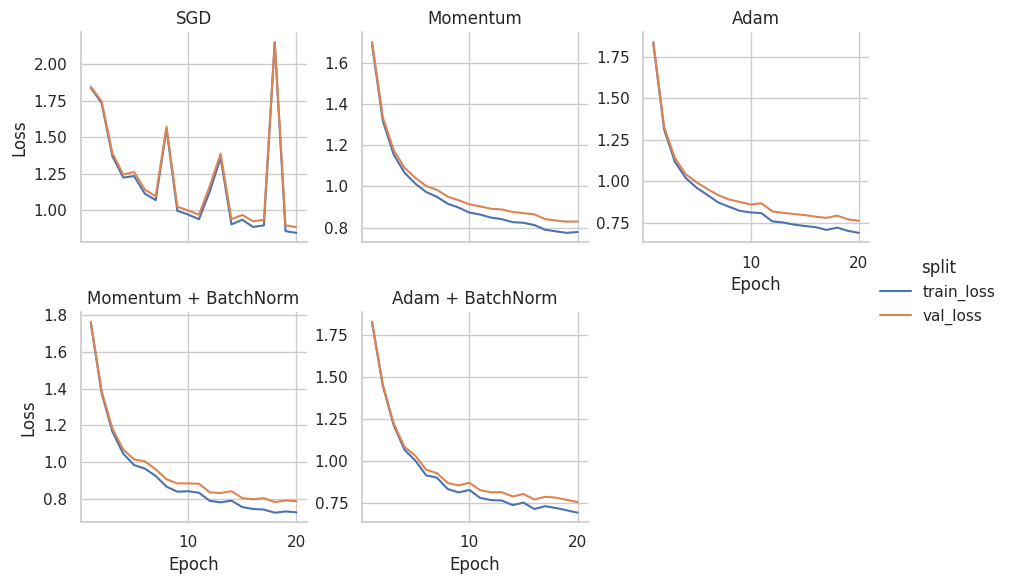

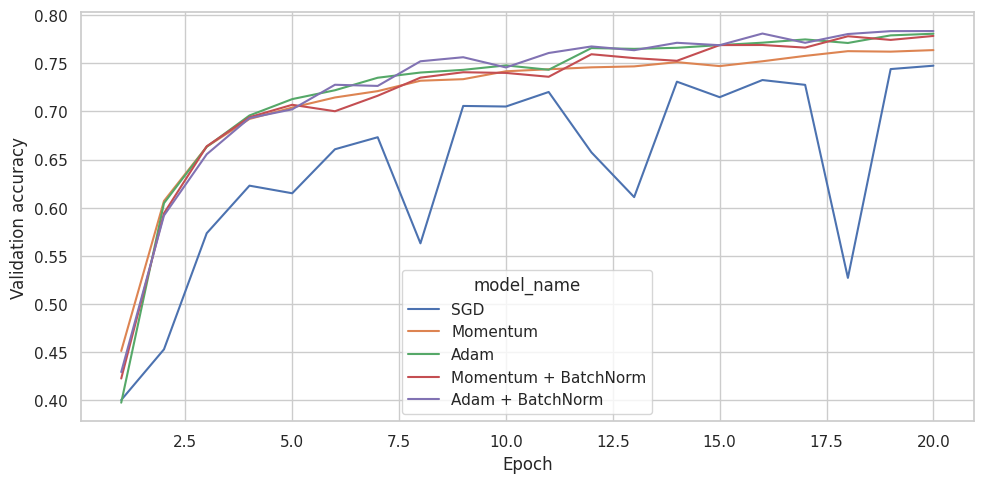

In [14]:
loss_history = comparison_history.melt(
    id_vars=["epoch", "model_name"],
    value_vars=["train_loss", "val_loss"],
    var_name="split",
    value_name="loss",
)
grid = sns.relplot(
    data=loss_history,
    x="epoch",
    y="loss",
    hue="split",
    col="model_name",
    col_wrap=3,
    kind="line",
    height=3,
    facet_kws={"sharey": False},
)
grid.set_titles("{col_name}")
grid.set_axis_labels("Epoch", "Loss")
plt.show()

sns.lineplot(data=comparison_history, x="epoch", y="val_accuracy", hue="model_name")
plt.xlabel("Epoch")
plt.ylabel("Validation accuracy")
plt.tight_layout()
plt.show()

SGD при `lr=0.1` даёт скачки loss; Momentum при `lr=0.01` сходится ровнее.

У Adam + BatchNorm итоговый train/val loss — `0.692 / 0.756`. Устойчивого роста val loss нет; сильного переобучения за 20 эпох не видно.

Лучшие варианты с BatchNorm опережают варианты без него на validation: Momentum — на 1,47 п.п., Adam — на 0,28 п.п. LR в каждой конфигурации свой.

## 5. Тест

Оцениваем сохранённую лучшую эпоху победителя по validation.

In [15]:
best_model_name = comparison_summary.iloc[0]["model_name"]
best_model = trained_models[best_model_name]

test_metrics = evaluate(
    best_model, CrossEntropyLoss(), X_test, y_test, batch_size=BATCH_SIZE, l2=L2
)
y_test_pred = best_model.predict(X_test)

print("Best model:", best_model_name)
print("Test loss:", round(test_metrics["loss"], 4))
print("Test accuracy:", round(test_metrics["accuracy"], 4))

Best model: Adam + BatchNorm
Test loss: 0.8912
Test accuracy: 0.7562


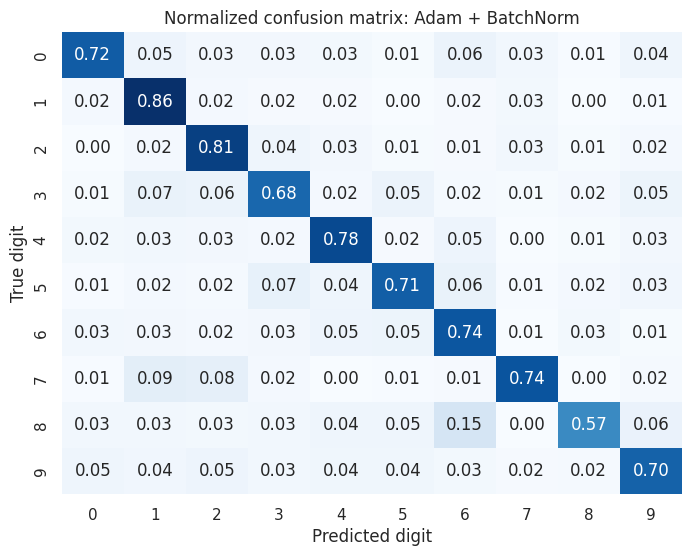

In [16]:
confusion = pd.crosstab(
    pd.Series(y_test, name="true"),
    pd.Series(y_test_pred, name="predicted"),
    normalize="index",
)

plt.figure(figsize=(8, 6))
sns.heatmap(confusion, annot=True, fmt=".2f", cmap="Blues", cbar=False)
plt.title(f"Normalized confusion matrix: {best_model_name}")
plt.xlabel("Predicted digit")
plt.ylabel("True digit")
plt.show()

## 6. Результат

Adam + BatchNorm, LR `0.003`, эпоха 20. Accuracy: validation — **78,35%**, test — **75,62%**.